# Empirical Study: Impact of Latent Space Statistics on Output Depth Scale and Shift

This notebook presents an empirical study investigating how the **mean** ($\mu$) and
**standard deviation** ($\sigma$) of intermediate latent features in a monocular geometry
estimation model ([MoGe](https://wangrc.site/MoGePage/)) affect the **scale**, **shift**,
and **accuracy** of the predicted depth maps.

## Motivation

Single-image depth estimation models typically predict depth up to an unknown scale and shift.
When aggregating predictions across multiple frames (e.g., for video depth estimation),
understanding what controls this scale-shift ambiguity is crucial. We hypothesize that the
first-order statistics of intermediate latent features, specifically their spatial mean and
standard deviation, play a significant role in determining the output scale and shift.

## Experimental Setup

We systematically perturb the latent features by applying multipliers to their mean and
standard deviation, then observe the resulting changes in:
1. **Alignment Scale** ($s$): the least-squares scale factor aligning predicted depth to ground truth
2. **Alignment Shift** ($t$): the least-squares shift aligning predicted depth to ground truth
3. **AbsRel Error**: the mean absolute relative error after alignment

## Mathematical Formulation

Given an input image, the backbone (DINOv2) extracts multi-scale features that are projected
and summed to produce a latent representation $\mathbf{x} \in \mathbb{R}^{C \times H \times W}$.

We normalize and re-parameterize $\mathbf{x}$ with controlled multipliers
$\alpha$ (mean) and $\beta$ (std):

$$
\bar{\mathbf{x}} = \frac{\mathbf{x} - \mu_{\mathbf{x}}}{\sigma_{\mathbf{x}}}, \quad
\mathbf{x}' = \bar{\mathbf{x}} \cdot (\beta \cdot \sigma_{\mathbf{x}})
             + (\alpha \cdot \mu_{\mathbf{x}})
$$

where $\mu_{\mathbf{x}}$ and $\sigma_{\mathbf{x}}$ are the spatial mean and standard
deviation of $\mathbf{x}$.

- When $\alpha = 1, \beta = 1$: the original features are recovered exactly.
- $\alpha > 1$: amplified mean → biased latent representation.
- $\beta > 1$: amplified variance → increased feature contrast.

The decoder maps $\mathbf{x}'$ to a depth map $\hat{d}$, which is aligned to the ground
truth $d^*$ via least-squares:

$$
d^* \approx s \cdot \hat{d} + t, \quad
\text{AbsRel} = \frac{1}{N} \sum_{i}
\frac{|d^*_i - (s \cdot \hat{d}_i + t)|}{d^*_i}
$$

In [1]:
import sys
sys.path.append("..")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import utils3d
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm import tqdm
from decord import VideoReader, cpu

from moge.model.v1 import MoGeModel
from moge.utils.geometry_torch import normalized_view_plane_uv, recover_focal_shift

## Configuration

Modify the paths and parameters below for your environment.

In [2]:
# ─── Paths (modify these for your environment) ───────────────────────────
PRETRAINED_MODEL_PATH = "Ruicheng/moge-vitl"

INDOOR_IMAGE_PATH = "../assets/video_data/scene0707_00_first_image.png"
INDOOR_DEPTH_PATH = "../assets/video_data/scene0707_00_first_depth.npy"

OUTDOOR_IMAGE_PATH = "../assets/video_data/market_2_first_image.png"
OUTDOOR_DEPTH_PATH = "../assets/video_data/market_2_first_depth.npy"

# ─── Experiment parameters ───────────────────────────────────────────────
DEVICE     = "cuda"
TARGET_FPS = 15
MAX_RES    = 1024
NUM_TOKENS = 1500

MEAN_RANGE = np.linspace(0.5, 2.0, 20)   # alpha sweep
STD_RANGE  = np.linspace(0.5, 2.0, 20)   # beta  sweep

# ─── Depth evaluation bounds ─────────────────────────────────────────────
DEPTH_MIN = 1e-3
DEPTH_MAX = 20.0

In [3]:
print("Loading pretrained MoGe model...")
model = MoGeModel.from_pretrained(PRETRAINED_MODEL_PATH).to(DEVICE).eval()
print("Model loaded successfully.")

Loading pretrained MoGe model...


/home/u6en/shawlyu.u6en/Opensourced/DyFN_MoGE/jupyter_demo/../moge/model/v1.py:245: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")


Initializing ConvGRU Stabilizer: gamma->0, beta->0.
Model loaded successfully.


## Core Functions

The experiment pipeline consists of four stages:
1. **`read_video_frames`** — load video and sample frames at a target FPS.
2. **`extract_backbone_features`** — preprocess a single frame and extract DINOv2 features.
3. **`decode_with_adjusted_features`** — apply $(\alpha, \beta)$ perturbation to the latent
   features and decode to depth.
4. **`compute_alignment_metrics`** — align predicted depth to ground truth and compute metrics.

In [4]:
def read_video_frames(video_path, target_fps=15, max_res=1024):
    """Read video frames and return as a float32 array in [0, 1]."""
    vid = VideoReader(video_path, ctx=cpu(0))
    original_h, original_w = vid.get_batch([0]).shape[1:3]
    vid = VideoReader(video_path, ctx=cpu(0), width=original_w, height=original_h)

    fps = vid.get_avg_fps() if target_fps == -1 else target_fps
    stride = max(round(vid.get_avg_fps() / fps), 1)
    frames_idx = list(range(0, len(vid), stride))

    frames = vid.get_batch(frames_idx).asnumpy().astype("float32") / 255.0
    return frames, fps


@torch.no_grad()
def extract_backbone_features(model, image_tensor, num_tokens=1500):
    """
    Preprocess a single image and extract backbone features.

    Returns:
        hidden_states, image_14, original_height, original_width
    """
    _, _, orig_h, orig_w = image_tensor.shape

    resize_factor = ((num_tokens * 14 ** 2) / (orig_h * orig_w)) ** 0.5
    rh, rw = int(orig_h * resize_factor), int(orig_w * resize_factor)
    image_resized = F.interpolate(
        image_tensor, (rh, rw), mode="bicubic", align_corners=False, antialias=True
    )
    image_normed = (image_resized - model.image_mean) / model.image_std
    image_14 = F.interpolate(
        image_normed, (rh // 14 * 14, rw // 14 * 14),
        mode="bilinear", align_corners=False, antialias=True
    )
    hidden_states = model.backbone.get_intermediate_layers(
        image_14, model.intermediate_layers, return_class_token=True
    )
    return hidden_states, image_14, orig_h, orig_w


@torch.no_grad()
def decode_with_adjusted_features(
    model, hidden_states, image_14, orig_h, orig_w,
    mean_multiplier=1.0, std_multiplier=1.0,
):
    """
    Run the MoGe decoder head with perturbed latent statistics.

        x' = x_norm * (beta * sigma) + (alpha * mu)

    Returns:
        depth: (H, W) tensor
    """
    img_h, img_w = image_14.shape[-2:]
    patch_h, patch_w = img_h // 14, img_w // 14

    x = torch.stack([
        proj(feat.permute(0, 2, 1).unflatten(2, (patch_h, patch_w)).contiguous())
        for proj, (feat, _) in zip(model.head.projects, hidden_states)
    ], dim=1).sum(dim=1)

    # Normalize -> perturb -> reconstruct
    x_mean = x.mean(dim=[2, 3], keepdim=True)
    x_std  = x.std(dim=[2, 3], keepdim=True)
    x_norm = (x - x_mean) / (x_std + 1e-6)
    x = x_norm * (std_multiplier * x_std) + (mean_multiplier * x_mean)

    # Upsample blocks
    for block in model.head.upsample_blocks:
        uv = normalized_view_plane_uv(
            width=x.shape[-1], height=x.shape[-2],
            aspect_ratio=img_w / img_h, dtype=x.dtype, device=x.device
        ).permute(2, 0, 1).unsqueeze(0).expand(x.shape[0], -1, -1, -1)
        x = torch.cat([x, uv], dim=1)
        for layer in block:
            x = torch.utils.checkpoint.checkpoint(layer, x, use_reentrant=False)

    x = F.interpolate(x, (img_h, img_w), mode="bilinear", align_corners=False)
    uv = normalized_view_plane_uv(
        width=x.shape[-1], height=x.shape[-2],
        aspect_ratio=img_w / img_h, dtype=x.dtype, device=x.device
    ).permute(2, 0, 1).unsqueeze(0).expand(x.shape[0], -1, -1, -1)
    x = torch.cat([x, uv], dim=1)

    if isinstance(model.head.output_block, nn.ModuleList):
        output = [
            torch.utils.checkpoint.checkpoint(blk, x, use_reentrant=False)
            for blk in model.head.output_block
        ]
    else:
        output = torch.utils.checkpoint.checkpoint(
            model.head.output_block, x, use_reentrant=False
        )
    points, mask = output

    with torch.autocast(device_type=image_14.device.type, dtype=torch.float32):
        points = F.interpolate(
            points, (orig_h, orig_w), mode="bilinear", align_corners=False
        ).permute(0, 2, 3, 1)
        mask = F.interpolate(
            mask, (orig_h, orig_w), mode="bilinear", align_corners=False
        )
        points = model._remap_points(points)

    mask_binary = mask.squeeze(1) > model.mask_threshold
    focal, shift = recover_focal_shift(points, mask_binary)
    depth = (points[..., 2] + shift[..., None, None]).squeeze()
    return depth


def compute_alignment_metrics(pred_depth, gt_depth,
                              depth_min=1e-3, depth_max=20.0):
    """
    Align predicted depth to ground truth via least-squares and compute metrics.

    Returns:
        scale (float), shift (float), absrel (float)
    """
    if isinstance(pred_depth, torch.Tensor):
        pred_depth = pred_depth.cpu().numpy()

    pred_depth = np.squeeze(pred_depth)
    gt_depth   = np.squeeze(gt_depth)

    pred_resized = F.interpolate(
        torch.from_numpy(pred_depth).float()[None, None],
        size=gt_depth.shape[-2:], mode="bilinear", align_corners=False
    ).squeeze().numpy()

    valid = (gt_depth > depth_min) & (gt_depth < depth_max)
    pred_v = pred_resized[valid].reshape(-1, 1)
    gt_v   = gt_depth[valid].reshape(-1, 1)

    A = np.concatenate([pred_v, np.ones_like(pred_v)], axis=-1)
    X = np.linalg.lstsq(A, gt_v, rcond=None)[0]
    scale, shift = float(X[0, 0]), float(X[1, 0])

    aligned = np.clip(scale * pred_v + shift, depth_min, depth_max)
    absrel  = float(np.nanmean(np.abs(gt_v - aligned) / (gt_v + 1e-6)))
    return scale, shift, absrel


def run_experiment(model, image_tensor, gt_depth, frame_index,
                   mean_range, std_range, num_tokens=1500,
                   depth_min=1e-3, depth_max=20.0):
    """
    Sweep over (alpha, beta) grid and collect alignment metrics for one frame.

    Returns:
        dict with 'scale', 'shift', 'absrel' (each n_mean x n_std),
        and 'mean_range', 'std_range'.
    """
    image_i = image_tensor[frame_index][None, ...]
    gt_depth_i = gt_depth[frame_index]

    hidden_states, image_14, orig_h, orig_w = extract_backbone_features(
        model, image_i, num_tokens
    )

    records = []
    total = len(mean_range) * len(std_range)

    with tqdm(total=total, desc="Sweeping (alpha, beta)") as pbar:
        for alpha in mean_range:
            for beta in std_range:
                depth = decode_with_adjusted_features(
                    model, hidden_states, image_14, orig_h, orig_w,
                    mean_multiplier=alpha, std_multiplier=beta,
                )
                s, t, ar = compute_alignment_metrics(
                    depth, gt_depth_i, depth_min, depth_max
                )
                records.append({"alpha": alpha, "beta": beta,
                                "scale": s, "shift": t, "absrel": ar})
                pbar.update(1)

    n_m, n_s = len(mean_range), len(std_range)
    return {
        "scale":      np.array([r["scale"]  for r in records]).reshape(n_m, n_s),
        "shift":      np.array([r["shift"]  for r in records]).reshape(n_m, n_s),
        "absrel":     np.array([r["absrel"] for r in records]).reshape(n_m, n_s),
        "mean_range": mean_range,
        "std_range":  std_range,
    }

## Visualization Functions

In [5]:
def plot_heatmaps(results, scene_name=""):
    """Plot 2D heatmaps of scale, shift, and AbsRel over the (alpha, beta) grid."""
    mr, sr = results["mean_range"], results["std_range"]
    mg, sg = np.meshgrid(mr, sr, indexing="ij")

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    pfx = f"{scene_name} \u2014 " if scene_name else ""

    # --- Scale ---
    c1 = axes[0].pcolormesh(mg, sg, results["scale"],
                            cmap="viridis", shading="auto", vmin=0.0, vmax=3.0)
    axes[0].set_xlabel(r"Mean multiplier $\alpha$", fontsize=14)
    axes[0].set_ylabel(r"Std multiplier $\beta$", fontsize=14)
    axes[0].set_title(f"{pfx}Alignment Scale", fontsize=15, weight="bold")
    fig.colorbar(c1, ax=axes[0], label="Scale")

    # --- Shift (diverging) ---
    vlim = np.nanmax(np.abs(results["shift"]))
    c2 = axes[1].pcolormesh(mg, sg, results["shift"],
                            cmap="coolwarm", shading="auto",
                            vmin=-vlim, vmax=vlim)
    axes[1].set_xlabel(r"Mean multiplier $\alpha$", fontsize=14)
    axes[1].set_ylabel(r"Std multiplier $\beta$", fontsize=14)
    axes[1].set_title(f"{pfx}Alignment Shift", fontsize=15, weight="bold")
    fig.colorbar(c2, ax=axes[1], label="Shift")

    # --- AbsRel ---
    vmax = max(np.nanpercentile(results["absrel"], 95), 0.01)
    c3 = axes[2].pcolormesh(mg, sg, results["absrel"],
                            cmap="inferno_r", shading="auto",
                            vmin=0.0, vmax=vmax)
    axes[2].set_xlabel(r"Mean multiplier $\alpha$", fontsize=14)
    axes[2].set_ylabel(r"Std multiplier $\beta$", fontsize=14)
    axes[2].set_title(f"{pfx}AbsRel Error", fontsize=15, weight="bold")
    fig.colorbar(c3, ax=axes[2], label="AbsRel (lower is better)")

    # Mark minimum-error point
    mi = np.unravel_index(np.nanargmin(results["absrel"]),
                          results["absrel"].shape)
    axes[2].plot(
        mg[mi], sg[mi], "w*", markersize=15, markeredgecolor="black",
        label=(f"Min AbsRel: {results['absrel'][mi]:.4f}\n"
               rf"($\alpha$={mg[mi]:.2f}, $\beta$={sg[mi]:.2f})"),
    )
    axes[2].legend(loc="upper right", fontsize=12)

    plt.tight_layout()
    plt.show()


def plot_1d_slices(results, scene_name=""):
    """Plot 1D slices of each metric vs. alpha (fixed beta) and vs. beta (fixed alpha)."""
    mr, sr = results["mean_range"], results["std_range"]
    n_m, n_s = len(mr), len(sr)

    # Reference point (alpha=1, beta=1)
    ia1 = int(np.argmin(np.abs(mr - 1.0)))
    ib1 = int(np.argmin(np.abs(sr - 1.0)))

    # Representative slices
    si_beta  = np.linspace(0, n_s - 1, 3, dtype=int)
    si_alpha = np.linspace(0, n_m - 1, 3, dtype=int)

    colors  = ["#3E4F94", "#3E90BF", "#FFD153"]
    markers = ["o", "s", "v"]

    grids   = [results["scale"], results["shift"], results["absrel"]]
    ylabels = ["Alignment Scale", "Alignment Shift", "AbsRel Error"]
    ref_labels = [
        r"Scale($\alpha\!=\!1,\beta\!=\!1$)",
        r"Shift($\alpha\!=\!1,\beta\!=\!1$)",
        r"AbsRel($\alpha\!=\!1,\beta\!=\!1$)",
    ]

    pfx = f"{scene_name} \u2014 " if scene_name else ""
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    for ax, grid, ylabel, rlabel in zip(axes, grids, ylabels, ref_labels):
        ref_val = grid[ia1, ib1]

        # Vary alpha with fixed beta
        for idx, (i, c) in enumerate(zip(si_beta, colors)):
            ax.plot(mr, grid[:, i], color=c, ls="-", lw=2,
                    marker=markers[idx], ms=6,
                    label=rf"vs. $\alpha$ ($\beta$={sr[i]:.2f})")
        # Vary beta with fixed alpha
        for idx, (i, c) in enumerate(zip(si_alpha, colors)):
            ax.plot(sr, grid[i, :], color=c, ls=":", lw=2,
                    marker=markers[idx], ms=6,
                    label=rf"vs. $\beta$ ($\alpha$={mr[i]:.2f})")

        ax.axhline(y=ref_val, color="k", ls=":", lw=1)
        h, _ = ax.get_legend_handles_labels()
        h.append(Line2D([0], [0], color="k", ls=":", label=rlabel))
        ax.legend(handles=h, loc="upper left", ncol=2, fontsize=12)

        ax.set_xlabel(r"Multiplier value ($\alpha$ or $\beta$)", fontsize=14)
        ax.set_ylabel(ylabel, fontsize=14)
        ax.set_title(f"{pfx}{ylabel} vs. Multiplier", fontsize=15, weight="bold")
        ax.grid(True, ls="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

---
## Experiment 1: Indoor Scene (ScanNet)

In [6]:
image_indoor = plt.imread(INDOOR_IMAGE_PATH)
if image_indoor.ndim == 2:
    image_indoor = np.stack([image_indoor] * 3, axis=-1)
if image_indoor.shape[-1] == 4:
    image_indoor = image_indoor[..., :3]
image_indoor = image_indoor.astype("float32")
if image_indoor.max() > 1.0:
    image_indoor = image_indoor / 255.0

frames_indoor = image_indoor[None, ...]
image_tensor_indoor = torch.from_numpy(frames_indoor).permute(0, 3, 1, 2).to(DEVICE)
gt_depth_indoor = np.load(INDOOR_DEPTH_PATH)[None, ...]

INDOOR_FRAME_INDEX = 0
print(f"Indoor scene: {frames_indoor.shape[0]} image loaded, "
      f"using frame index {INDOOR_FRAME_INDEX}")

results_indoor = run_experiment(
    model, image_tensor_indoor, gt_depth_indoor,
    frame_index=INDOOR_FRAME_INDEX,
    mean_range=MEAN_RANGE, std_range=STD_RANGE,
    num_tokens=NUM_TOKENS, depth_min=DEPTH_MIN, depth_max=DEPTH_MAX,
)

Indoor scene: 1 image loaded, using frame index 0


Sweeping (alpha, beta): 100%|██████████████████████████| 400/400 [00:14<00:00, 28.25it/s]


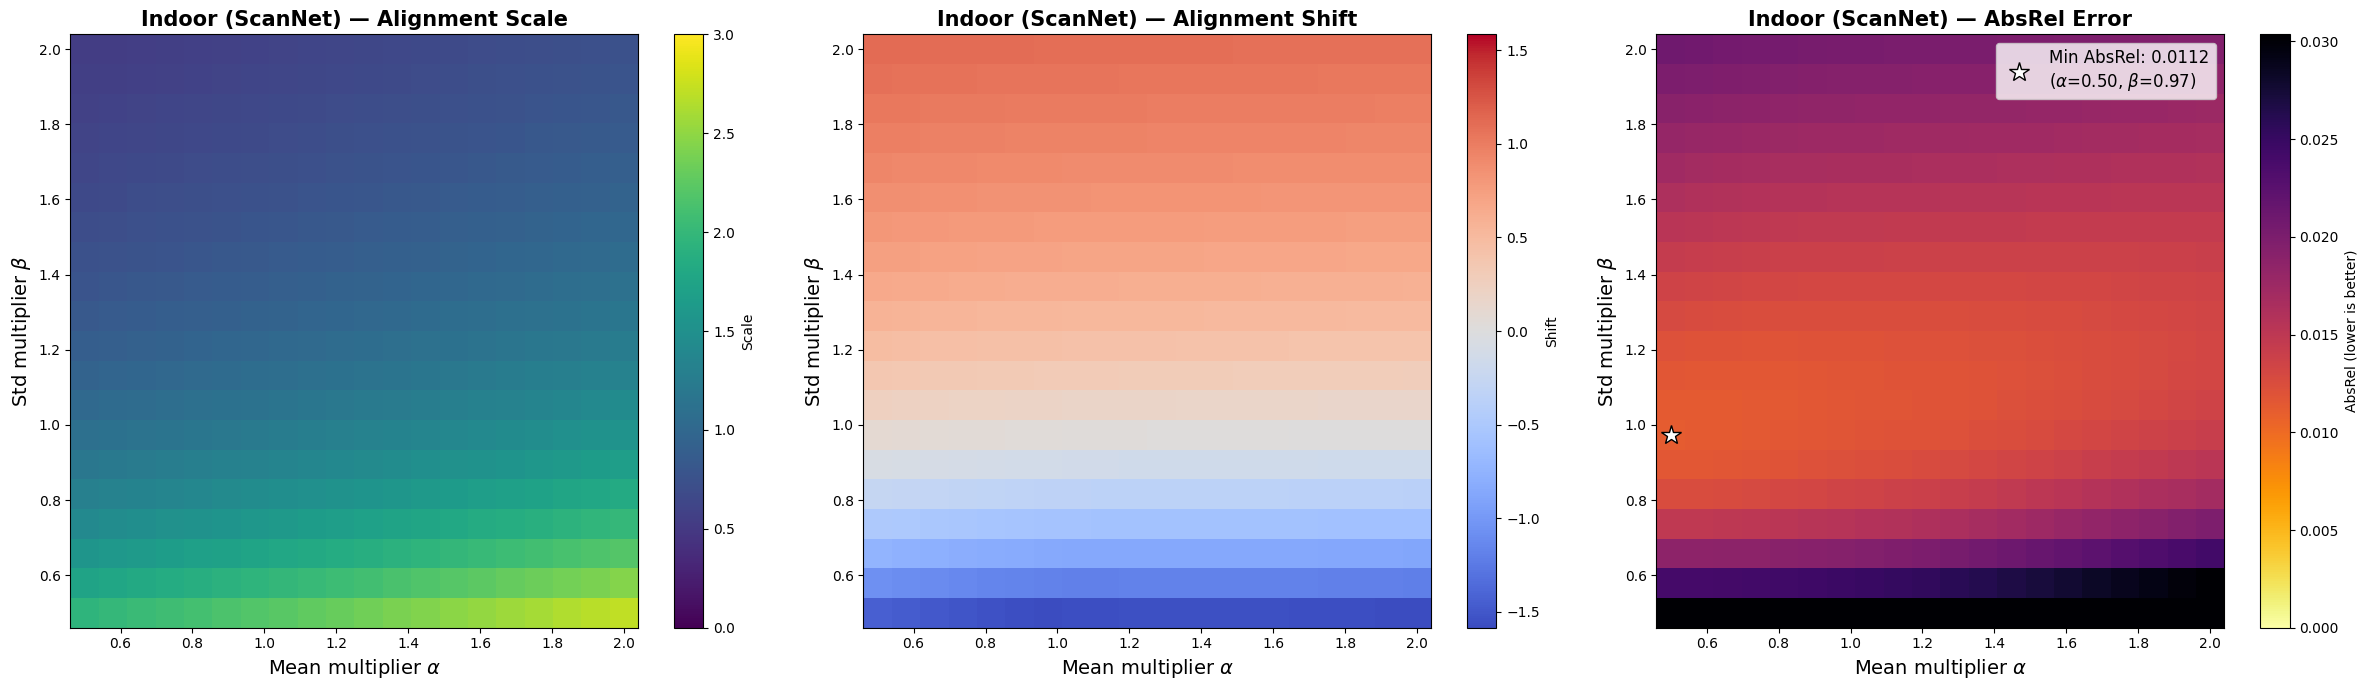

In [7]:
plot_heatmaps(results_indoor, scene_name="Indoor (ScanNet)")

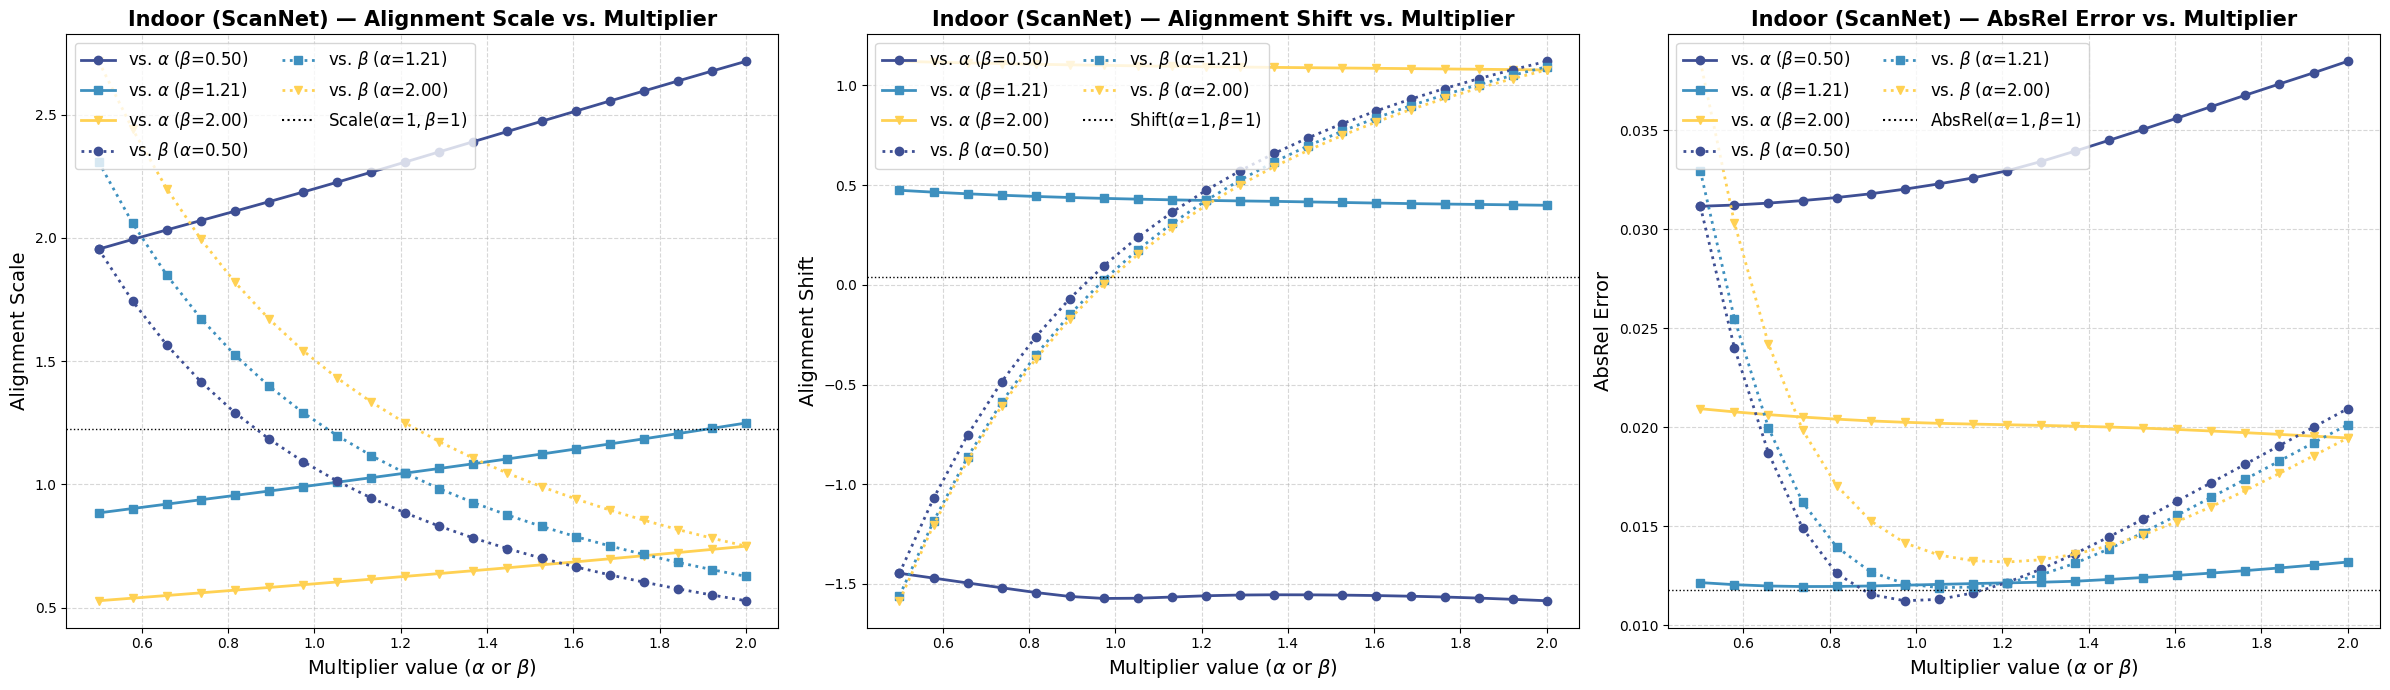

In [8]:
plot_1d_slices(results_indoor, scene_name="Indoor (ScanNet)")

---
## Experiment 2: Outdoor Scene (Sintel)

In [ ]:
image_outdoor = plt.imread(OUTDOOR_IMAGE_PATH)
if image_outdoor.ndim == 2:
    image_outdoor = np.stack([image_outdoor] * 3, axis=-1)
if image_outdoor.shape[-1] == 4:
    image_outdoor = image_outdoor[..., :3]
image_outdoor = image_outdoor.astype("float32")
if image_outdoor.max() > 1.0:
    image_outdoor = image_outdoor / 255.0

frames_outdoor = image_outdoor[None, ...]
image_tensor_outdoor = torch.from_numpy(frames_outdoor).permute(0, 3, 1, 2).to(DEVICE)
gt_depth_outdoor = np.load(OUTDOOR_DEPTH_PATH)[None, ...]

OUTDOOR_FRAME_INDEX = 0
print(f"Outdoor scene: {frames_outdoor.shape[0]} image loaded, "
      f"using frame index {OUTDOOR_FRAME_INDEX}")

results_outdoor = run_experiment(
    model, image_tensor_outdoor, gt_depth_outdoor,
    frame_index=OUTDOOR_FRAME_INDEX,
    mean_range=MEAN_RANGE, std_range=STD_RANGE,
    num_tokens=NUM_TOKENS, depth_min=DEPTH_MIN, depth_max=DEPTH_MAX,
)

Outdoor scene: 1 image loaded, using frame index 0


Sweeping (alpha, beta):  93%|████████████████████████  | 371/400 [00:09<00:00, 38.93it/s]

In [ ]:
plot_heatmaps(results_outdoor, scene_name="Outdoor (Sintel)")

In [ ]:
plot_1d_slices(results_outdoor, scene_name="Outdoor (Sintel)")

---
## Summary of Findings

This empirical study reveals clear relationships between latent space statistics and output
depth properties:

1. **Mean multiplier $\alpha$ primarily controls alignment shift**: Increasing $\alpha$
   leads to a monotonic change in the alignment shift $t$, while having a moderate effect
   on scale.

2. **Std multiplier $\beta$ primarily controls alignment scale**: Increasing $\beta$ leads
   to a monotonic change in the alignment scale $s$, with less impact on the shift.

3. **Accuracy (AbsRel) is most sensitive near the original operating point**: Both $\alpha$
   and $\beta$ deviations from $1.0$ degrade accuracy, with the degradation being roughly
   symmetric around the original point.

These findings suggest that normalizing and controlling the first-order statistics of latent
features across frames could be an effective strategy for achieving temporally consistent
scale and shift in video depth estimation.